## 1.Daten laden

In diesem Schritt laden wir den Datensatz und verschaffen uns einen ersten Überblick über
die Struktur und Inhalte der Daten. Dazu verwenden wir zunächst die Python-Bibliothek **pandas**,
die sich ideal für tabellarische Daten eignet.

In [2]:
import pandas as pd

Dann laden wir die Daten:

In [3]:
df = pd.read_csv('../data/raw/wage_data.csv')
df.head()

,wage,educ,exper,tenure,nonwhite,female,married
0,3.10,11,2,0,0,1,0
1,3.24,12,22,2,0,1,1
2,3.00,11,2,0,0,0,0
3,6.00,8,44,28,0,0,1
4,5.30,12,7,2,0,0,1


Der Datensatz enthält insgesamt **7 Variablen**, die persönliche und berufliche Merkmale von Personen beschreiben:

- **wage** – Stundenlohn
- **educ** – Anzahl der Bildungsjahre
- **exper** – Berufserfahrung in Jahren
- **tenure** – Zugehörigkeitsdauer im aktuellen Job
- **nonwhite** – Indikator für ethnische Zugehörigkeit (0 = white, 1 = nonwhite)
- **female** – Geschlecht (0 = männlich, 1 = weiblich)
- **married** – Familienstand (0 = unverheiratet, 1 = verheiratet)

Für das Regressionsmodell definieren wir:

- **Zielvariable (y):** `wage`  
- **Features (X):** `educ`, `exper`, `tenure`, `nonwhite`, `female`, `married`

Damit modellieren wir, wie stark diese sechs Faktoren die abhängige Variable `wage` beeinflussen.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   wage      526 non-null    float64
 1   educ      526 non-null    int64  
 2   exper     526 non-null    int64  
 3   tenure    526 non-null    int64  
 4   nonwhite  526 non-null    int64  
 5   female    526 non-null    int64  
 6   married   526 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 28.9 KB


### Datenstruktur und Qualität

Die `df.info()`-Ausgabe liefert einen Überblick über den Aufbau des Datensatzes:

- **Zeilen:** 526 Beobachtungen  
- **Spalten:** 7 Variablen  
- **Fehlende Werte:** Keine (`526 non-null` in jeder Spalte)  
- **Datentypen:**  
  - `wage` ist eine kontinuierliche numerische Variable (float64)  
  - die übrigen Variablen sind kategoriale oder diskrete numerische Variablen (int64)

Dies bedeutet:
- Der Datensatz ist vollständig und benötigt keine Imputation von fehlenden Werten.
- Alle Variablen sind bereits in einem ML-freundlichen Format.
- Für Modelle wie lineare Regression oder KNN sind keine Typkonvertierungen notwendig.

Die Spalte `wage` kann als **Zielvariable (y)** verwendet werden, während die übrigen 6 Spalten als **Feature-Variablen (X)** geeignet sind.

In [5]:
df.describe()

,wage,educ,exper,tenure,nonwhite,female,married
count,526.000000,526.000000,526.00000,526.000000,526.000000,526.000000,526.000000
mean,5.896103,12.562738,17.01711,5.104563,0.102662,0.479087,0.608365
std,3.693086,2.769022,13.57216,7.224462,0.303805,0.500038,0.488580
min,0.530000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000
25%,3.330000,12.000000,5.00000,0.000000,0.000000,0.000000,0.000000
50%,4.650000,12.000000,13.50000,2.000000,0.000000,0.000000,1.000000
75%,6.880000,14.000000,26.00000,7.000000,0.000000,1.000000,1.000000
max,24.980000,18.000000,51.00000,44.000000,1.000000,1.000000,1.000000


### Statistische Übersicht der Daten (`df.describe()`)

Die statistische Zusammenfassung gibt einen ersten quantitativen Eindruck über die Verteilung der Variablen im Datensatz. Für jede numerische Spalte werden grundlegende Kennzahlen wie Mittelwert, Standardabweichung sowie Min-/Max-Werte und Quartile angezeigt. 

**Wichtige Beobachtungen:**

- **wage**  
  - Der durchschnittliche Stundenlohn beträgt rund **5.90**.  
  - Der Lohn variiert stark (Standardabweichung ≈ **3.69**), mit Werten zwischen **0.53** und **24.98**.  
  - Diese Streuung deutet auf mögliche Ausreißer hin, die im weiteren Verlauf untersucht werden sollten.

- **educ (Bildungsjahre)**  
  - Median: **12 Jahre**, 75%-Quantil: **14 Jahre**  
  - Der Bereich reicht von **0** bis **18** Jahren, was auf unterschiedliche Bildungsniveaus hinweist.

- **exper (Berufserfahrung)**  
  - Mittelwert: **17 Jahre**, Maximalwert: **51 Jahre**  
  - Die hohe Standardabweichung (≈ **13.57**) zeigt eine große Spannweite zwischen Einsteigern und sehr erfahrenen Beschäftigten.

- **tenure (Betriebszugehörigkeit)**  
  - Median: **4 Jahre**, Maximum **44 Jahre**  
  - Auch hier deutet eine große Streuung auf unterschiedliche Arbeitnehmerprofile hin.

- **nonwhite, female, married**  
  - Dies sind binäre Indikatorvariablen mit Werten 0/1.  
  - Die Mittelwerte entsprechen den relativen Anteilen in der Stichprobe:  
    - Anteil nicht-weißer Personen: **10,2 %**  
    - Anteil Frauen: **47,9 %**  
    - Anteil Verheirateter: **60,8 %**

**Fazit:**  
Die Daten sind vollständig (keine fehlenden Werte) und weisen sowohl kontinuierliche als auch kategoriale Variablen auf. Damit eignen sie sich gut für eine lineare Regression. Die breite Streuung bei Lohn, Erfahrung und Betriebszugehörigkeit kann Einfluss auf die Modellgüte haben und sollte im Modellierungsprozess berücksichtigt werden.

# 2.Feature Definition und Explorative Datenanalyse

In diesem Notebook definieren wir die Feature-Variablen (X) und die Zielvariable (y).

Wir importieren hier die benötigten Python-Bibliotheken für die explorative Analyse:

- **NumPy** (`numpy`) für mathematische Operationen und effiziente Arbeit mit Arrays.
- **Matplotlib** (`matplotlib.pyplot`) für die Erstellung von Visualisierungen wie Linien-, Scatter- oder Balkendiagrammen.

Diese Pakete helfen uns dabei, die Daten besser zu verstehen und erste Zusammenhänge sichtbar zu machen.

Anschließend teilen wir den Datensatz in **Trainings-**, **Validierungs-** und **Testdaten** auf.  
Dies stellt sicher, dass wir das Modell korrekt trainieren, optimieren und später objektiv bewerten können.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

### Variablen definieren

Wir trennen die Daten in:
- **X** (Features/Unabhängige Variablen): educ, exper, tenure, nonwhite, female, married
- **y** (Zielvariable/Abhängige Variable): wage

In [7]:
y = df['wage']

X = df[['educ', 'exper', 'tenure', 'nonwhite', 'female', 'married']]

print("Zielvariable (y) - Shape:", y.shape)
print("Features (X) - Shape:", X.shape)
print("\nFeature-Namen:")
print(X.columns.tolist())

Zielvariable (y) - Shape: (526,)
Features (X) - Shape: (526, 6)

Feature-Namen:
['educ', 'exper', 'tenure', 'nonwhite', 'female', 'married']


### Train-Test-Validation Split

Wir teilen die Daten in drei Teile auf:
- **Training (70%)**: Zum Trainieren des Modells
- **Validation (15%)**: Zum Tunen und Validieren des Modells während der Entwicklung
- **Test (15%)**: Zum finalen Testen des Modells auf unseen data

Dies ist eine bewährte Praxis, um Overfitting zu vermeiden und die echte Generalierungsfähigkeit zu testen.

In [9]:
from sklearn.model_selection import train_test_split

# Erste Split: 70% Train, 30% Temp (Test + Validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Zweite Split: Temp in 50% Test und 50% Validation
# (Das ergibt 15% Test und 15% Validation vom Original)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Datensatz aufgeteilt:")
print(f"Training Set: {X_train.shape[0]} Samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test Set:     {X_test.shape[0]} Samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Validation Set: {X_val.shape[0]} Samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"\nTotal: {X_train.shape[0] + X_test.shape[0] + X_val.shape[0]} Samples")

Datensatz aufgeteilt:
Training Set: 368 Samples (70.0%)
Test Set:     79 Samples (15.0%)
Validation Set: 79 Samples (15.0%)

Total: 526 Samples


### Aufgeteilte Daten speichern

Die Daten werden in CSV-Dateien gespeichert, damit sie in den nächsten Notebooks
direkt geladen und verwendet werden können.

In [10]:
# Speichern der Trainingsdaten
X_train.to_csv('../data/Cleaned/Train70/X_train_wage_data.csv', index=False)
y_train.to_csv('../data/Cleaned/Train70/y_train_wage_data.csv', index=False)

# Speichern der Testdaten
X_test.to_csv('../data/Cleaned/Test15/X_test_wage_data.csv', index=False)
y_test.to_csv('../data/Cleaned/Test15/y_test_wage_data.csv', index=False)
# Speichern der Validationsdaten
X_val.to_csv('../data/Cleaned/Validate15/X_val_wage_data.csv', index=False)
y_val.to_csv('../data/Cleaned/Validate15/y_val_wage_data.csv', index=False)

print("✓ Trainingsdaten gespeichert in ../data/Cleaned/Train70/")
print("✓ Testdaten gespeichert in ../data/Cleaned/Test15/")
print("✓ Validationsdaten gespeichert in ../data/Cleaned/Validate15/")

✓ Trainingsdaten gespeichert in ../data/Cleaned/Train70/
✓ Testdaten gespeichert in ../data/Cleaned/Test15/
✓ Validationsdaten gespeichert in ../data/Cleaned/Validate15/


# 3.Lineares Regressionsmodell

In diesem Abschnitt trainieren wir ein lineares Regressionsmodell zur Vorhersage des Stundenlohns (`wage`).  
Dafür laden wir die zuvor aufbereiteten Trainings-, Validierungs- und Testdaten, trainieren das Modell und bewerten dessen Leistung.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Trainings-, Validierungs- und Testdaten laden
Hier laden wir die bereits gesplitteten Datensätze, die im vorherigen Notebook erstellt wurden.
Die Daten bestehen aus:
- **X** → Eingangsvariablen (Features)
- **y** → Zielvariable (Stundenlohn)

In [12]:
# Trainingsdaten
X_train = pd.read_csv('../data/Cleaned/Train70/X_train_wage_data.csv')
y_train = pd.read_csv('../data/Cleaned/Train70/y_train_wage_data.csv')

# Validationsdaten
X_val = pd.read_csv('../data/Cleaned/Validate15/X_val_wage_data.csv')
y_val = pd.read_csv('../data/Cleaned/Validate15/y_val_wage_data.csv')

# Testdaten
X_test = pd.read_csv('../data/Cleaned/Test15/X_test_wage_data.csv')
y_test = pd.read_csv('../data/Cleaned/Test15/y_test_wage_data.csv')

### Überprüfung der Datenformen (Shapes)
Wir kontrollieren, ob die Datensätze korrekt geladen wurden und ob die Dimensionen stimmen.
- `X` enthält sechs Feature-Spalten
- `y` enthält die Zielgröße (wage)

In [13]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(368, 6) (368, 1)
(79, 6) (79, 1)
(79, 6) (79, 1)


### Lineares Regressionsmodell trainieren
Wir initialisieren ein `LinearRegression`-Modell und trainieren es auf den Trainingsdaten (`X_train`, `y_train`).

In [14]:
# Modell initialisieren
lin_reg = LinearRegression()

# Modell mit Trainingsdaten trainieren
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Modellbewertung (Training vs. Validation)
Wir berechnen den Fehler (MSE/RMSE) und das Bestimmtheitsmaß R² auf Trainings- und Validierungsdaten.
So sehen wir, wie gut das Modell passt und ob es evtl. über- oder unterfitten könnte.

In [15]:
# Vorhersagen
y_train_pred = lin_reg.predict(X_train)
y_val_pred   = lin_reg.predict(X_val)

# Fehlermaße
mse_train = mean_squared_error(y_train, y_train_pred)
mse_val   = mean_squared_error(y_val,   y_val_pred)

rmse_train = np.sqrt(mse_train)
rmse_val   = np.sqrt(mse_val)

r2_train = r2_score(y_train, y_train_pred)
r2_val   = r2_score(y_val,   y_val_pred)

print("Training:")
print(f"  RMSE: {rmse_train:.3f}")
print(f"  R²  : {r2_train:.3f}")

print("\nValidation:")
print(f"  RMSE: {rmse_val:.3f}")
print(f"  R²  : {r2_val:.3f}")

Training:
  RMSE: 2.912
  R²  : 0.366

Validation:
  RMSE: 2.809
  R²  : 0.390


### Modellkoeffizienten

In [21]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Koeffizient": lin_reg.coef_[0]
})

print("Intercept (Basislohn):", lin_reg.intercept_)
coef_df

Intercept (Basislohn): [-2.1677808]


,Feature,Koeffizient
0,educ,0.583396
1,exper,0.026222
2,tenure,0.152667
3,nonwhite,-0.131476
4,female,-1.621042
5,married,0.350028


Der **Intercept (Achsenabschnitt)** stellt den theoretischen Basislohn dar, falls alle Features den Wert 0 hätten.
Dieser Wert ist mathematisch notwendig, aber wirtschaftlich nicht real interpretierbar.

Die Koeffizienten der linearen Regression zeigen, wie sich der vorhergesagte Stundenlohn verändert,
wenn ein Feature um eine Einheit steigt, bei konstant gehaltenen anderen Variablen.

### Interpretation der Koeffizienten

- **educ (0.58)**  
  Ein zusätzliches Ausbildungsjahr erhöht den Stundenlohn im Durchschnitt um etwa **0.58 Einheiten**.

- **exper (0.03)**  
  Jedes zusätzliche Jahr Berufserfahrung steigert den Lohn leicht um ungefähr **0.03 Einheiten**.

- **tenure (0.15)**  
  Ein weiteres Jahr im gleichen Unternehmen erhöht den Lohn im Durchschnitt um **0.15 Einheiten**.

- **nonwhite (-0.13)**  
  Personen, die als „nonwhite“ klassifiziert sind, verdienen laut Modell durchschnittlich  
  **0.13 Einheiten weniger** als „white“-Personen.

- **female (-1.62)**  
  Frauen verdienen im Durchschnitt **1.62 Einheiten weniger** als Männer – selbst bei gleichen sonstigen Merkmalen.

- **married (0.35)**  
  Verheiratete Personen verdienen im Schnitt **0.35 Einheiten mehr**.

### Zusammenfassung

Die Koeffizienten zeigen, welche Variablen den größten Einfluss auf den Stundenlohn haben.
Negative Werte (z. B. für *female* oder *nonwhite*) weisen auf potenzielle Verzerrungen oder Ungleichheiten im Datensatz hin
und sollten nicht kausal interpretiert werden.

### Finale Evaluation auf dem Testdatensatz
Zum Schluss bewerten wir das Modell auf den zuvor komplett ungenutzten Testdaten.

In [22]:
y_test_pred = lin_reg.predict(X_test)

mse_test  = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test, y_test_pred)

print("Testdaten:")
print(f"  RMSE: {rmse_test:.3f}")
print(f"  R²  : {r2_test:.3f}")

Testdaten:
  RMSE: 3.183
  R²  : 0.324


## 4. Analysis

In [23]:
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [24]:
# Zielvariable als Series extrahieren (falls noch DataFrame)
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]

if isinstance(y_val, pd.DataFrame):
    y_val = y_val.iloc[:, 0]

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((368, 6), (368,), (79, 6), (79,))

In [25]:
# Falls y_train / y_val noch DataFrames sind → in Series umwandeln
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]

if isinstance(y_val, pd.DataFrame):
    y_val = y_val.iloc[:, 0]

print("y_train:", type(y_train), y_train.shape)
print("y_val:  ", type(y_val),   y_val.shape)

# Vorhersagen (1D-Arrays)
y_train_pred = lin_reg.predict(X_train)          # -> ndarray mit Shape (n_samples,)
y_val_pred   = lin_reg.predict(X_val)

print("y_train_pred:", type(y_train_pred), y_train_pred.shape)
print("y_val_pred:  ", type(y_val_pred),   y_val_pred.shape)

y_train: <class 'pandas.core.series.Series'> (368,)
y_val:   <class 'pandas.core.series.Series'> (79,)
y_train_pred: <class 'numpy.ndarray'> (368, 1)
y_val_pred:   <class 'numpy.ndarray'> (79, 1)


In [26]:
# Residuen berechnen (Fehler: Ist - Vorhersage)

# sicherheitshalber nochmal 1D machen
y_train = y_train.squeeze()
y_val   = y_val.squeeze()

# Vorhersagen auf 1D bringen
y_train_pred = np.array(y_train_pred).ravel()
y_val_pred   = np.array(y_val_pred).ravel()

# Residuen berechnen
residuals_train = y_train - y_train_pred
residuals_val   = y_val   - y_val_pred

print("residuals_train:", type(residuals_train), residuals_train.shape)
print("residuals_val:  ", type(residuals_val),   residuals_val.shape)

residuals_train: <class 'pandas.core.series.Series'> (368,)
residuals_val:   <class 'pandas.core.series.Series'> (79,)


### Residuen prüfen

In [27]:
print("len(y_train):", len(y_train))
print("len(y_train_pred):", len(y_train_pred))
print("len(residuals_train):", len(residuals_train))

print("\nlen(y_val):", len(y_val))
print("len(y_val_pred):", len(y_val_pred))
print("len(residuals_val):", len(residuals_val))

len(y_train): 368
len(y_train_pred): 368
len(residuals_train): 368

len(y_val): 79
len(y_val_pred): 79
len(residuals_val): 79


Alle drei Längen pro Datensatz müssen gleich sein.

### Histogramm der Residuen

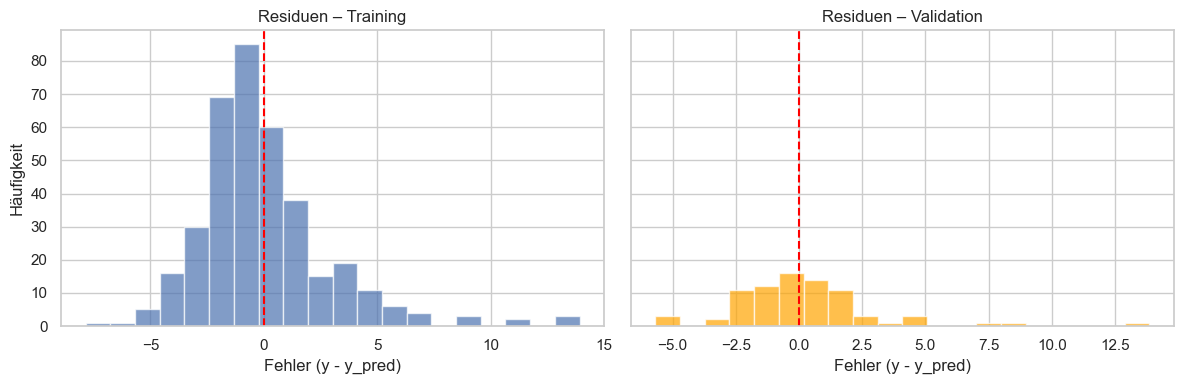

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(residuals_train, bins=20, alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residuen – Training")
axes[0].set_xlabel("Fehler (y - y_pred)")
axes[0].set_ylabel("Häufigkeit")

axes[1].hist(residuals_val, bins=20, alpha=0.7, color="orange")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residuen – Validation")
axes[1].set_xlabel("Fehler (y - y_pred)")

plt.tight_layout()
plt.show()

Die Histogramme zeigen die Verteilung der Residuen (Fehler \(y - \hat{y}\)) getrennt für
Trainings- und Validierungsdaten.

- **Training:** 
Die Residuen sind grob symmetrisch um 0 verteilt, die meisten Werte liegen in einem
moderaten Bereich. Es gibt einige wenige Ausreißer mit größeren Fehlern. Insgesamt
deutet das darauf hin, dass das lineare Modell die Daten im Mittel gut trifft, aber
einzelne Beobachtungen schlechter erklärt werden.

- **Validation:** 
Die Residuen der Validierungsdaten liegen in einem ähnlichen Bereich wie im Training
und sind ebenfalls um 0 zentriert. Da hier weniger Datenpunkte vorliegen, wirkt das
Histogramm etwas grober, zeigt aber kein systematisches Muster (kein deutlicher
Shift nach links oder rechts).

**Fazit:** 
Das Modell scheint weder stark über- noch unterzufitten. Die Fehlerverteilung auf
Trainings- und Validierungsdaten ist vergleichbar und die Residuen sind im Mittel
nahe bei 0, was für ein sinnvoll angepasstes lineares Regressionsmodell spricht.

True vs. Predicted (Validation)

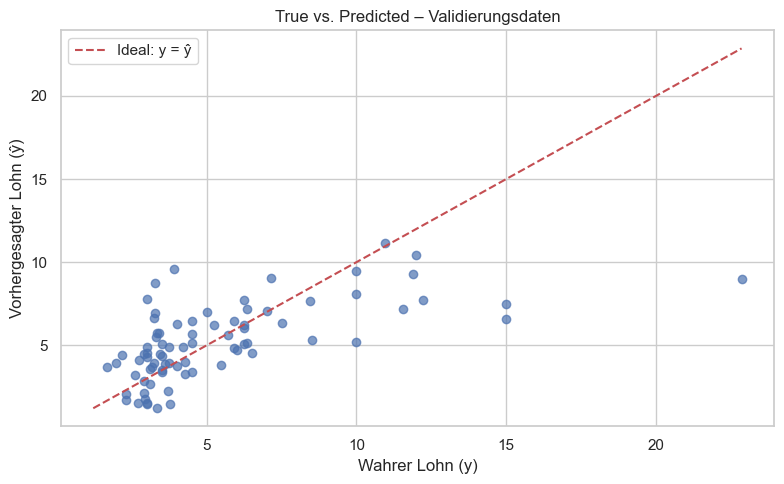

In [29]:
plt.figure()
plt.scatter(y_val, y_val_pred, alpha=0.7)
min_y = min(y_val.min(), y_val_pred.min())
max_y = max(y_val.max(), y_val_pred.max())
plt.plot([min_y, max_y], [min_y, max_y], "r--", label="Ideal: y = ŷ")

plt.xlabel("Wahrer Lohn (y)")
plt.ylabel("Vorhergesagter Lohn (ŷ)")
plt.title("True vs. Predicted – Validierungsdaten")
plt.legend()
plt.tight_layout()
plt.show()


Beispiel: Zusammenhang eines Features mit dem Lohn

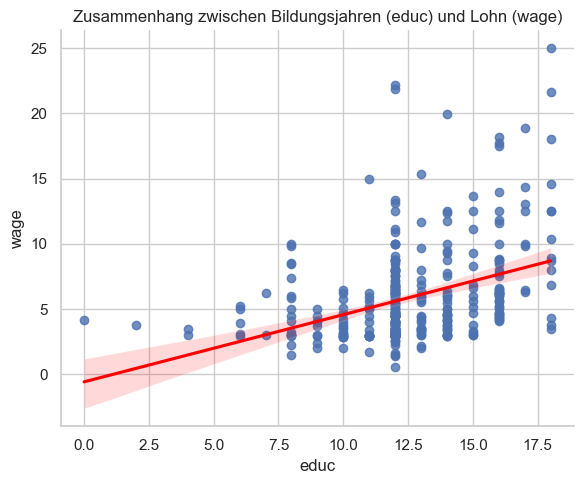

In [30]:
sns.lmplot(
    data=pd.concat([X_train, y_train.rename("wage")], axis=1),
    x="educ", y="wage",
    height=5, aspect=1.2,
    line_kws={"color": "red"}
)

plt.title("Zusammenhang zwischen Bildungsjahren (educ) und Lohn (wage)")
plt.tight_layout()
plt.show()

In [31]:
print("len(y_train):", len(y_train))
print("len(y_train_pred):", len(y_train_pred))
print("len(residuals_train):", len(residuals_train))

print("\nlen(y_val):", len(y_val))
print("len(y_val_pred):", len(y_val_pred))
print("len(residuals_val):", len(residuals_val))

len(y_train): 368
len(y_train_pred): 368
len(residuals_train): 368

len(y_val): 79
len(y_val_pred): 79
len(residuals_val): 79


# 5.Model Verbesserung

In [32]:
# Beispiel: Interaktion zwischen Bildung und Erfahrung
X_train['educ_exper'] = X_train['educ'] * X_train['exper']
X_val['educ_exper'] = X_val['educ'] * X_val['exper']

# Beispiel: Polynomterm für Bildung
X_train['educ_sq'] = X_train['educ'] ** 2
X_val['educ_sq'] = X_val['educ'] ** 2

# 6.Vorhersage

In [34]:
# Neue Person (Beispielwerte)
new_person = pd.DataFrame({
    "educ": [12],        # 12 Jahre Ausbildung
    "exper": [5],        # 5 Jahre Berufserfahrung
    "tenure": [1],       # 1 Jahr im aktuellen Job
    "nonwhite": [0],     # 0 = white
    "female": [1],       # 1 = female
    "married": [0]       # 0 = nicht verheiratet
})

new_person

,educ,exper,tenure,nonwhite,female,married
0,12,5,1,0,1,0


In [37]:
# Vorhersage durchführen
predicted_wage = lin_reg.predict(new_person)   # Shape (1, 1) oder (1,)

# auf Skalar runterbrechen
predicted_value = float(predicted_wage.ravel()[0])   # oder predicted_wage[0, 0]

print(f"Vorhergesagter Lohn (wage): {predicted_value:.2f}")

Vorhergesagter Lohn (wage): 3.50
